[*********************100%***********************]  3 of 3 completed


--- Optimal Portfolio Weights (Max Sharpe Ratio) ---
OrderedDict({'BND': 0.43787, 'SPY': 0.56213, 'TSLA': 0.0})
Expected annual return: 7.9%
Annual volatility: 10.4%
Sharpe Ratio: 0.76


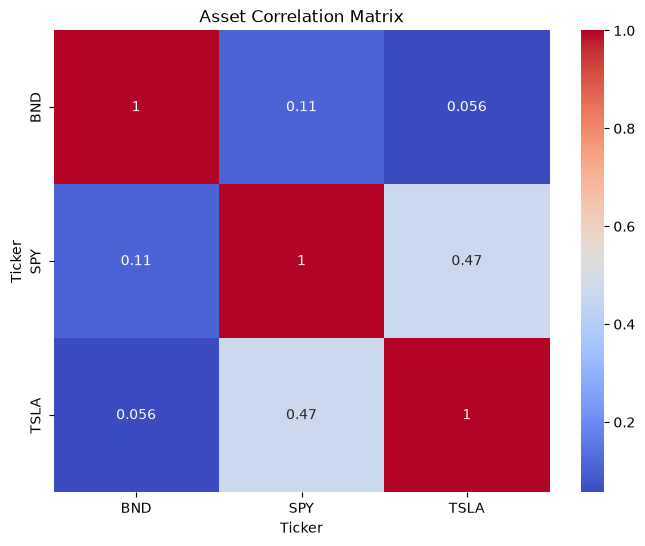

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models, expected_returns, plotting

# 1. Fetch Data for all three assets
assets = ['TSLA', 'BND', 'SPY']
data = yf.download(assets, start='2015-01-01', end='2025-01-01', auto_adjust=True)['Close']
data = data.dropna()

# 2. Define Expected Returns (mu)
# For BND and SPY, we use historical averages
mu_historical = expected_returns.mean_historical_return(data[['BND', 'SPY']])

# For TSLA, we use your Forecasted Return (from Task 3)
# Let's say: (Last Forecast Price - Last Actual Price) / Last Actual Price
# Based on your plot, it looks like a negative return of approx -30% annually
mu_tsla = -0.30 

mu = pd.Series({'BND': mu_historical['BND'], 'SPY': mu_historical['SPY'], 'TSLA': mu_tsla})

# 3. Calculate Risk (Covariance Matrix)
S = risk_models.sample_cov(data)

# 4. Generate the Efficient Frontier
ef = EfficientFrontier(mu, S)

# Find the portfolio that maximizes the Sharpe Ratio
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

print("--- Optimal Portfolio Weights (Max Sharpe Ratio) ---")
print(cleaned_weights)

# 5. Performance Metrics
performance = ef.portfolio_performance(verbose=True)

# 6. Visualize the Covariance Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data.pct_change().corr(), annot=True, cmap='coolwarm')
plt.title('Asset Correlation Matrix')
plt.show()